In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importar tablas

In [147]:
clusters = pd.read_csv('../data/processed/clusters.csv')
members = pd.read_csv('../data/processed/members.csv')


La siguiente función permite seleccionar regiones de los diagramas.

In [148]:
def cuts(df, bp_g_min, bp_g_max, g_rp_min, g_rp_max):
    mask = (df['BP-G'] > bp_g_min) & (df['BP-G'] < bp_g_max) & (df['G-RP'] > g_rp_min) & (df['G-RP'] < g_rp_max)
    
    cut = df[mask]

    bp_g = cut['BP-G']
    g_rp = cut['G-RP']
    bp_rp = cut['BP-RP']
    gmag = cut['Gmag']
    return bp_g, g_rp, bp_rp, gmag

## Cúmulos globulares

Se filtran los cúmulos globulares.

In [149]:
globular_clusters = clusters[clusters['Type'] == 'g']

Se selecciona el cúmulo globular con más miembros.

In [150]:
max_index = globular_clusters['N'].idxmax()
globular_clusters_name = globular_clusters.loc[max_index, 'Name']

In [151]:
globular_cluster = globular_clusters[
    globular_clusters['Name'] == globular_clusters_name]

globular_cluster_members = members[members['Name'] == globular_clusters_name]

Se seleccionan los colores en la banda G de Gaia y también la magnitud G de los miembros del cúmulo globular.

In [152]:
globular_bp_g = globular_cluster_members['BP-G'].values
globular_g_rp = globular_cluster_members['G-RP'].values
globular_bp_rp = globular_cluster_members['BP-RP'].values
globular_g_mag = globular_cluster_members['Gmag'].values

Se realizan los recortes específicos para diferenciar en qué lugar se encuentran las diferentes partes del diagrama Color-Color en el diagrama Color-Magnitud del cúmulo.

In [153]:
globular_chulo = cuts(globular_cluster_members, -1.5, 0.49, 0.69, 3)
globular_bulto = cuts(globular_cluster_members, 0.2, 2, -0.5, 0.69)
globular_cola_inf = cuts(globular_cluster_members, -1.5, 0.19, -1, 0.5)
globular_cola_sup = cuts(globular_cluster_members, 0.5, 2, 0.7, 3)

### Diagramas

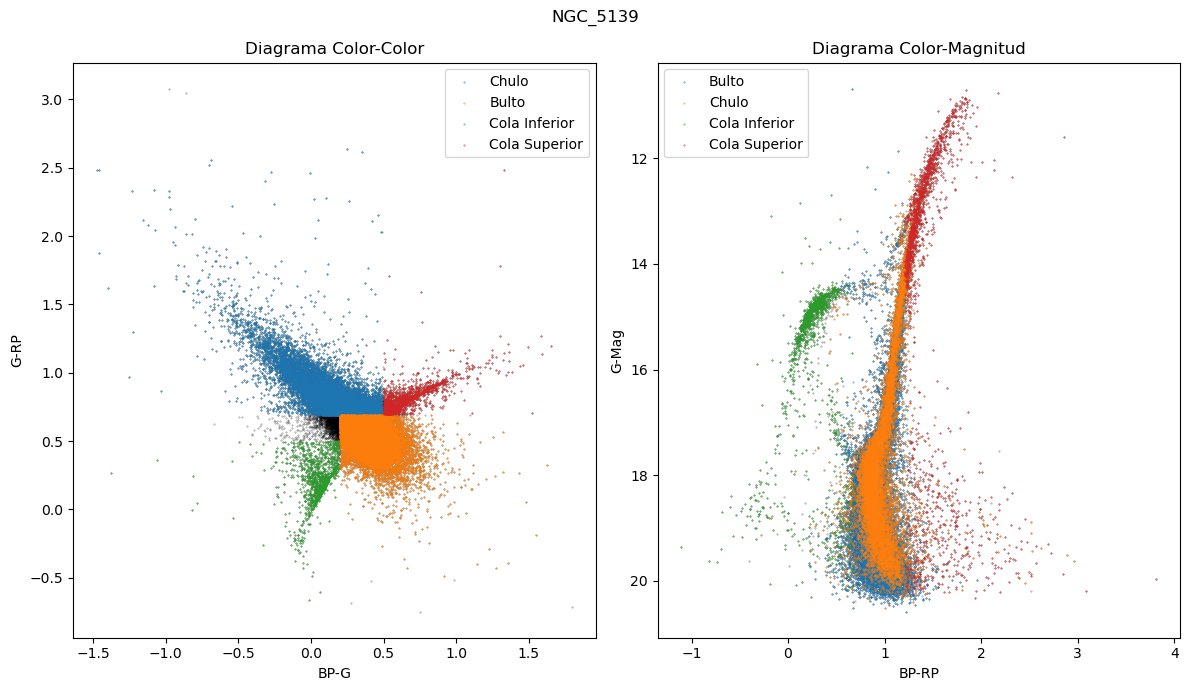

In [154]:
fig, ax = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle(f"{globular_clusters_name}")

ax[0].scatter(globular_bp_g, globular_g_rp, s=0.1, color='k', alpha=0.5)
ax[0].scatter(globular_chulo[0], globular_chulo[1], s=0.1, label='Chulo')
ax[0].scatter(globular_bulto[0], globular_bulto[1], s=0.1, label='Bulto')
ax[0].scatter(globular_cola_inf[0], globular_cola_inf[1], s=0.1, label='Cola Inferior')
ax[0].scatter(globular_cola_sup[0], globular_cola_sup[1], s=0.1, label='Cola Superior')
ax[0].set_xlabel('BP-G')
ax[0].set_ylabel('G-RP')
ax[0].set_title('Diagrama Color-Color')
ax[0].legend()

ax[1].scatter(globular_bp_rp, globular_g_mag, s=0.1, color='k', alpha=0.5)
ax[1].scatter(globular_bulto[2], globular_bulto[3], s=0.1, label='Bulto')
ax[1].scatter(globular_chulo[2], globular_chulo[3], s=0.1, label='Chulo')
ax[1].scatter(globular_cola_inf[2], globular_cola_inf[3], s=0.1, label='Cola Inferior')
ax[1].scatter(globular_cola_sup[2], globular_cola_sup[3], s=0.1, label='Cola Superior')
ax[1].set_xlabel('BP-RP')
ax[1].set_ylabel('G-Mag')
ax[1].set_title('Diagrama Color-Magnitud')
ax[1].legend()
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Cúmulos abiertos

Se filtran los cúmulos abiertos.

In [155]:
open_clusters = clusters[clusters['Type'] == 'o']

Se selecciona el cúmulo abierto con más miembros.

In [156]:
max_index = open_clusters['N'].idxmax()
open_cluster_name = open_clusters.loc[max_index, 'Name']

In [157]:
open_cluster = clusters[clusters['Name'] == open_cluster_name]
open_cluster_members = members[members['Name'] == open_cluster_name]

Se seleccionan los colores en la banda G de Gaia y también la magnitud G de los miembros del cúmulo abierto.

In [158]:
open_bp_g = open_cluster_members['BP-G'].values
open_g_rp = open_cluster_members['G-RP'].values
open_bp_rp = open_cluster_members['BP-RP'].values
open_g_mag = open_cluster_members['Gmag'].values

Se realizan los recortes específicos para diferenciar en qué lugar se encuentran las diferentes partes del diagrama Color-Color en el diagrama Color-Magnitud del cúmulo.

In [159]:
open_chulo = cuts(open_cluster_members, 0.0, 0.55, 0.7, 1.01)
open_bulto = cuts(open_cluster_members, 0.42, 2.5, 0.54, 0.7)
open_cola_inf = cuts(open_cluster_members, -0.1, 0.42, -0.3, 0.55)
open_cola_sup = cuts(open_cluster_members, 0.6, 3, 0.75, 2)

### Diagramas

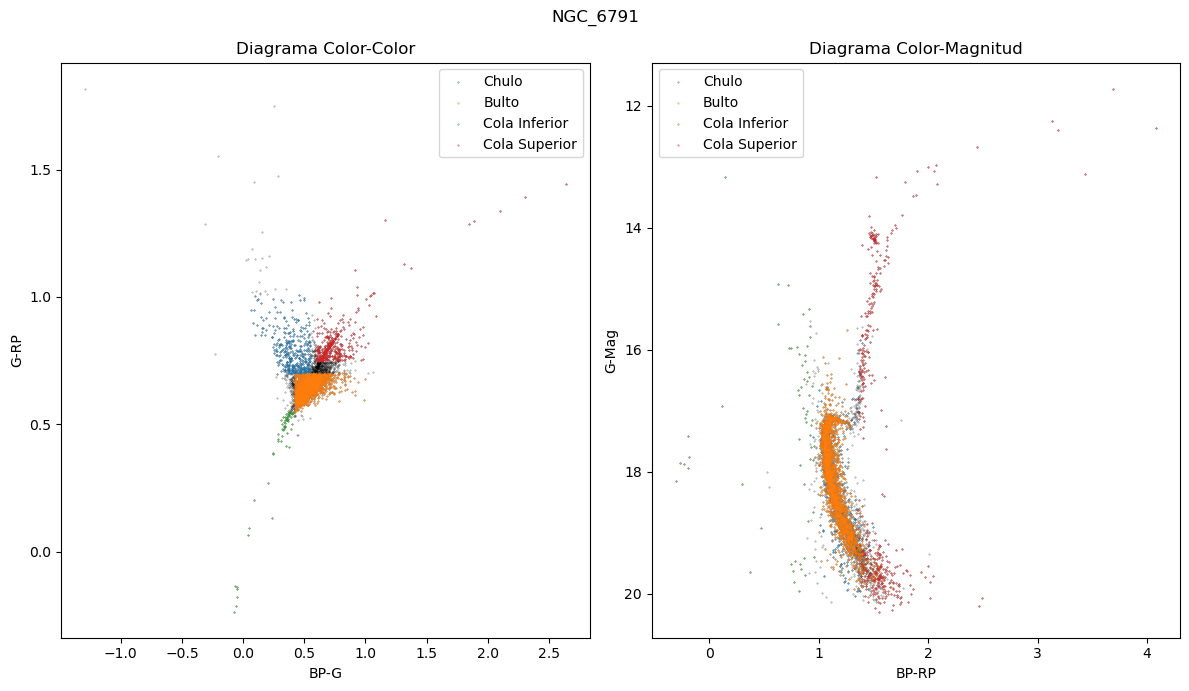

In [160]:
fig, ax = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle(f"{open_cluster_name}")

ax[0].scatter(open_bp_g, open_g_rp, s=0.1, color='k', alpha=0.5)
ax[0].scatter(open_chulo[0], open_chulo[1], s=0.1, label='Chulo')
ax[0].scatter(open_bulto[0], open_bulto[1], s=0.1, label='Bulto')
ax[0].scatter(open_cola_inf[0], open_cola_inf[1], s=0.1, label='Cola Inferior')
ax[0].scatter(open_cola_sup[0], open_cola_sup[1], s=0.1, label='Cola Superior')
ax[0].set_xlabel('BP-G')
ax[0].set_ylabel('G-RP')
ax[0].set_title('Diagrama Color-Color')
ax[0].legend()

ax[1].scatter(open_bp_rp, open_g_mag, s=0.1, color='k', alpha=0.5)
ax[1].scatter(open_chulo[2], open_chulo[3], s=0.1, label='Chulo')
ax[1].scatter(open_bulto[2], open_bulto[3], s=0.1, label='Bulto')
ax[1].scatter(open_cola_inf[2], open_cola_inf[3], s=0.1, label='Cola Inferior')
ax[1].scatter(open_cola_sup[2], open_cola_sup[3], s=0.1, label='Cola Superior')
ax[1].set_xlabel('BP-RP')
ax[1].set_ylabel('G-Mag')
ax[1].set_title('Diagrama Color-Magnitud')
ax[1].legend()
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

Para este cúmulo abierto el catálogo brinda las masas de los miembros, por lo tanto se seleccionan estas para analizar cómo están distribuidas las masas de los miembros en el diagrama Color-Color y comparar las posiciones con el diagrama Color-Magnitud.

In [161]:
open_cluster_masses = open_cluster_members['Mass50'].values

### Diagramas

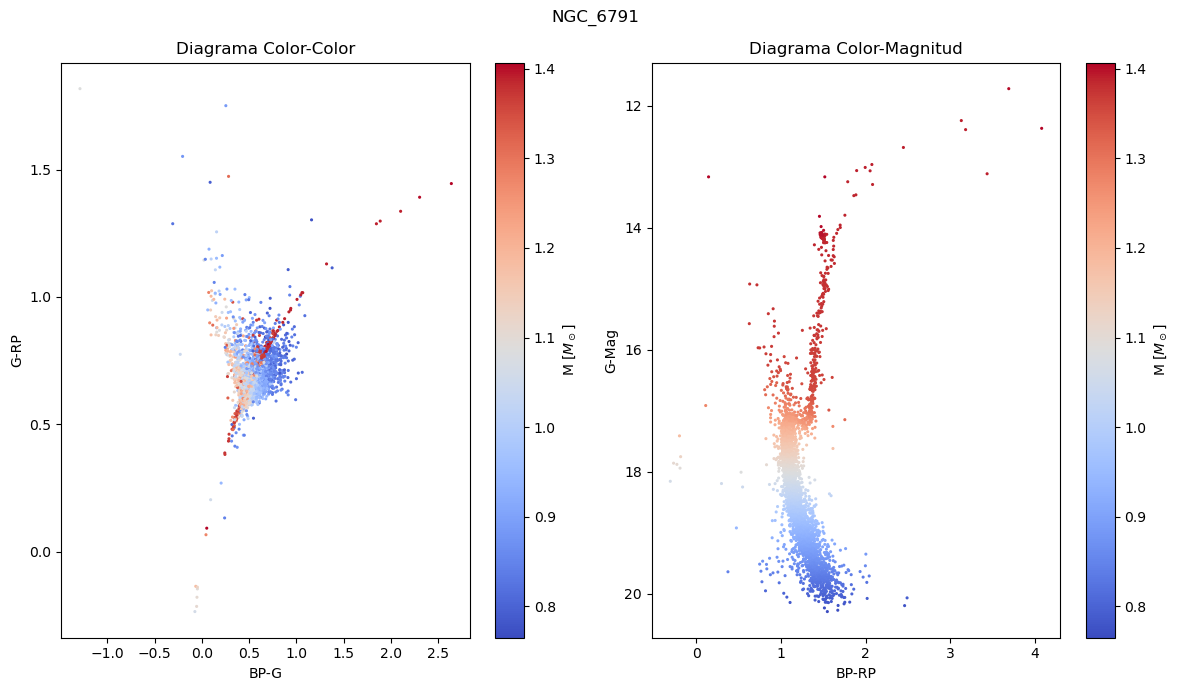

In [162]:
fig, ax = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle(f"{open_cluster_name}")

ax0 = ax[0].scatter(bp_g, g_rp, s=1.5, c=open_cluster_masses, cmap='coolwarm')
ax[0].set_xlabel('BP-G')
ax[0].set_ylabel('G-RP')
ax[0].set_title('Diagrama Color-Color')

fig.colorbar(ax0, ax=ax[0], label=r'M [$M_\odot$]')

ax1 = ax[1].scatter(bp_rp, g_mag, s=1.5, c=open_cluster_masses, cmap='coolwarm')
ax[1].set_xlabel('BP-RP')
ax[1].set_ylabel('G-Mag')
ax[1].set_title('Diagrama Color-Magnitud')
ax[1].invert_yaxis()

fig.colorbar(ax1, ax=ax[1], label=r'M [$M_\odot$]')

plt.tight_layout()
plt.show()


## Superposición de diagramas Color-Color

Para entender el comportamiento de los diagramas Color-Color para los diferentes cúmulos, se superponen los dos diagramas de los cúmulos, abierto y globular con más miembros.

### Diagramas

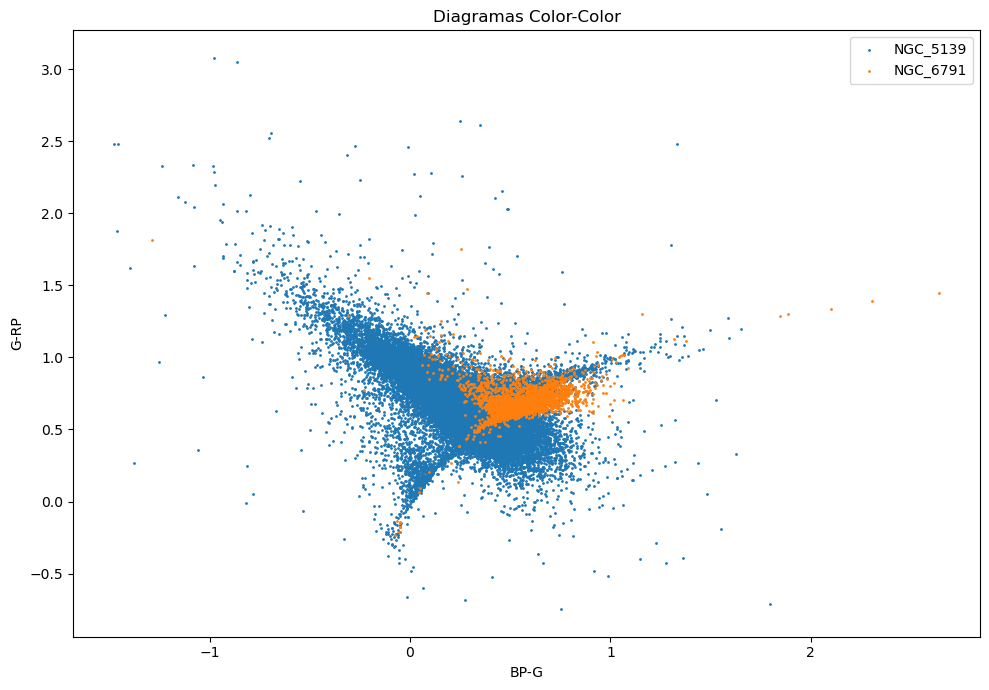

In [163]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(globular_bp_g, globular_g_rp, s=1, label=f'{globular_clusters_name}')
ax.scatter(open_bp_g, open_g_rp, s=1, label=f'{open_cluster_name}')
ax.set_xlabel('BP-G')
ax.set_ylabel('G-RP')
ax.set_title('Diagramas Color-Color')
ax.legend()

plt.tight_layout()
plt.show()